In [30]:
import yfinance as yf, pandas as pd, numpy as np
import matplotlib.pyplot as plt

tickers = ["HDFCBANK.NS", "ICICIBANK.NS", "AXISBANK.NS", "KOTAKBANK.NS",
           "TCS.NS", "INFY.NS", "HCLTECH.NS", "WIPRO.NS"]
px = yf.download(tickers, start="2021-01-01", auto_adjust=True)["Close"].dropna()
px.to_csv("../data/prices.csv")
print(px.shape)
px.tail()

[*********************100%***********************]  8 of 8 completed

(1422, 8)


Ticker,AXISBANK.NS,HCLTECH.NS,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,KOTAKBANK.NS,TCS.NS,WIPRO.NS
Date,,,,,,,,
2026-09-21,1250.000000,1281.000000,739.500000,1345.000000,1038.500000,414.799988,2128.699951,164.550003
2026-09-22,1242.699951,1270.400024,738.599976,1339.599976,1029.400024,412.649994,2105.000000,166.000000
2026-09-23,1243.199951,1256.699951,737.250000,1340.000000,1020.500000,413.250000,2089.600098,164.899994
2026-09-24,1186.500000,1243.599976,728.900024,1334.500000,1014.500000,405.000000,2087.000000,163.639999
2026-09-25,1222.400024,1258.000000,735.599976,1326.800049,1000.200012,404.000000,2082.000000,164.020004


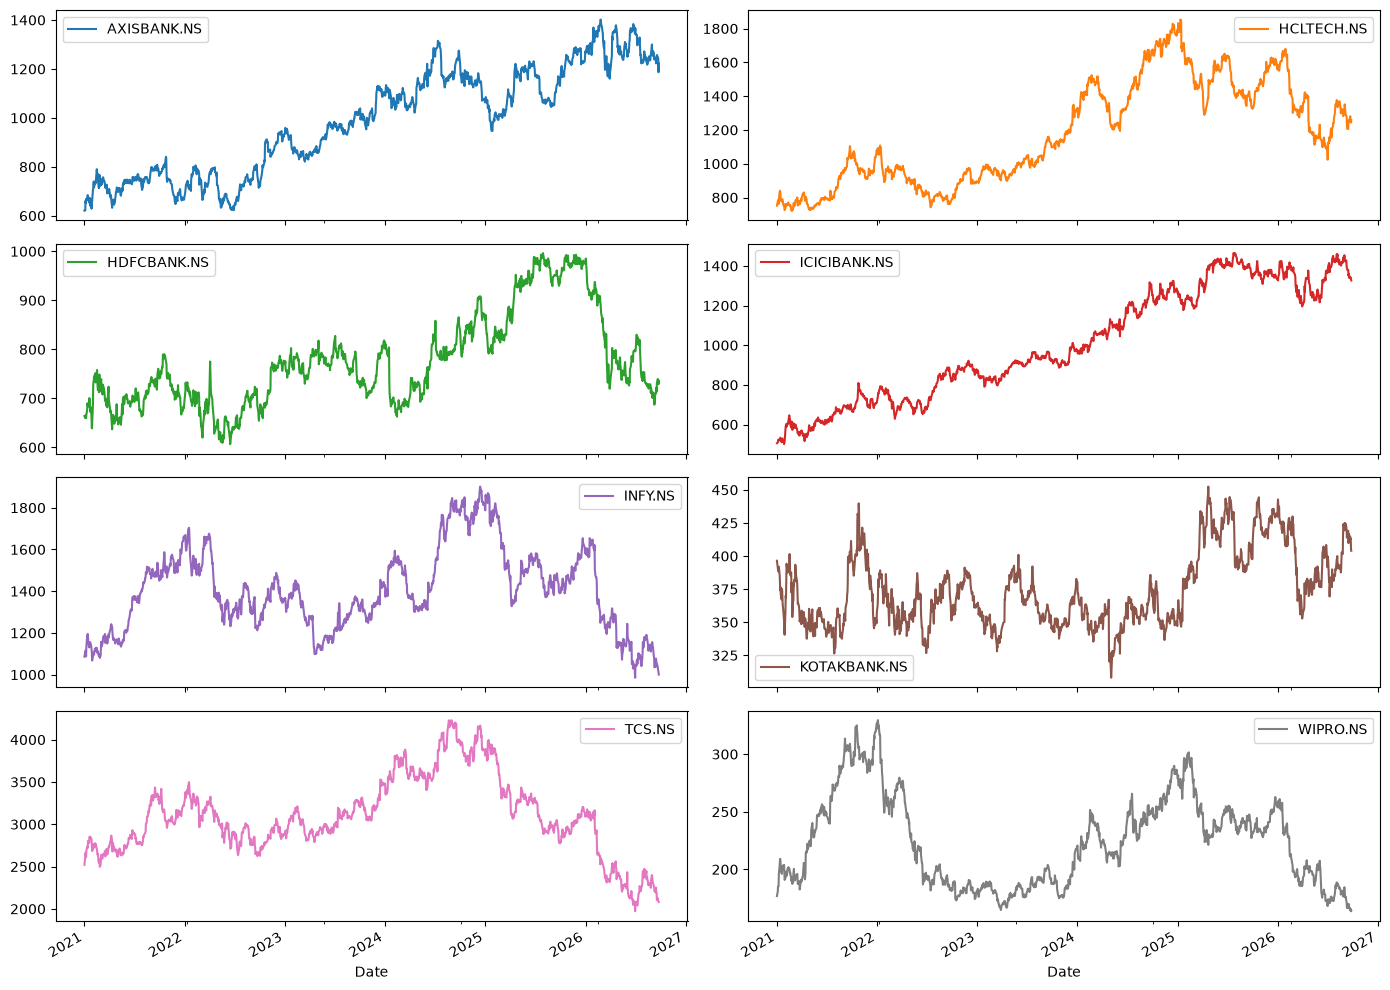

In [31]:
px.plot(subplots=True, layout=(4, 2), figsize=(14, 10))
plt.tight_layout()
plt.show()

In [32]:
split = "2025-01-01"
train = px[px.index < split]
test = px[px.index >= split]
logp = np.log(px)
print("Train:", train.index[0].date(), "to", train.index[-1].date(), len(train), "days")
print("Test: ", test.index[0].date(), "to", test.index[-1].date(), len(test), "days")

Train: 2021-01-01 to 2024-12-31 987 days
Test:  2025-01-01 to 2026-09-25 435 days


In [33]:
from statsmodels.tsa.stattools import coint

pairs = [("HDFCBANK.NS", "ICICIBANK.NS"), ("ICICIBANK.NS", "AXISBANK.NS"),
         ("KOTAKBANK.NS", "AXISBANK.NS"), ("TCS.NS", "INFY.NS"),
         ("HCLTECH.NS", "WIPRO.NS")]

results = []
for a, b in pairs:
    p = coint(np.log(train[a]), np.log(train[b]))[1]
    results.append((a, b, round(p, 4)))

pd.DataFrame(results, columns=["Stock A", "Stock B", "p-value"]).sort_values("p-value")

,Stock A,Stock B,p-value
2,KOTAKBANK.NS,AXISBANK.NS,0.0003
0,HDFCBANK.NS,ICICIBANK.NS,0.0473
1,ICICIBANK.NS,AXISBANK.NS,0.4256
3,TCS.NS,INFY.NS,0.4783
4,HCLTECH.NS,WIPRO.NS,0.9860


Intercept c: 6.1715
Hedge ratio beta: -0.0416


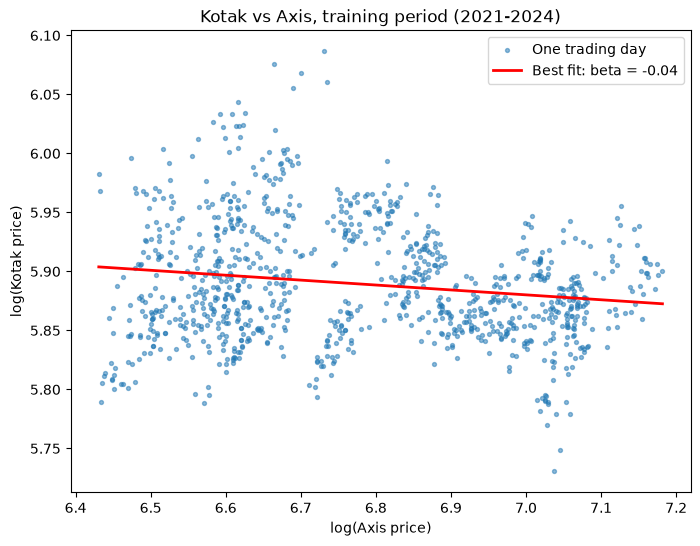

In [34]:
import statsmodels.api as sm

A, B = "KOTAKBANK.NS", "AXISBANK.NS"
x = np.log(train[B])
y = np.log(train[A])
model = sm.OLS(y, sm.add_constant(x)).fit()
c, beta = model.params["const"], model.params[B]
print("Intercept c:", round(c, 4))
print("Hedge ratio beta:", round(beta, 4))

plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=8, alpha=0.5, label="One trading day")
xs = np.linspace(x.min(), x.max(), 100)
plt.plot(xs, c + beta * xs, color="red", linewidth=2, label=f"Best fit: beta = {beta:.2f}")
plt.xlabel("log(Axis price)")
plt.ylabel("log(Kotak price)")
plt.title("Kotak vs Axis, training period (2021-2024)")
plt.legend()
plt.savefig("../charts/regression.png", dpi=150, bbox_inches="tight")
plt.show()

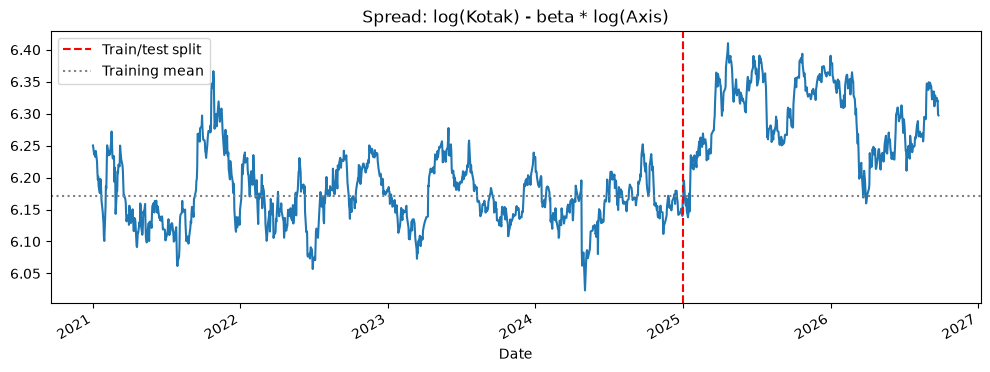

In [35]:
spread = logp[A] - beta * logp[B]

spread.plot(figsize=(12, 4), title="Spread: log(Kotak) - beta * log(Axis)")
plt.axvline(pd.Timestamp(split), color="red", linestyle="--", label="Train/test split")
plt.axhline(spread[spread.index < split].mean(), color="grey", linestyle=":", label="Training mean")
plt.legend()
plt.savefig("../charts/spread.png", dpi=150, bbox_inches="tight")
plt.show()

In [36]:
s = spread[spread.index < split]
lagged = sm.add_constant(s.shift(1).dropna())
lam = sm.OLS(s.diff().dropna(), lagged).fit().params.iloc[1]
half_life = -np.log(2) / lam
window = int(np.clip(round(2 * half_life), 20, 60))
print("Lambda:", round(lam, 4))
print("Half-life (days):", round(half_life, 1))
print("Z-score window:", window)

Lambda: -0.0483
Half-life (days): 14.3
Z-score window: 29


[*********************100%***********************]  7 of 7 completed


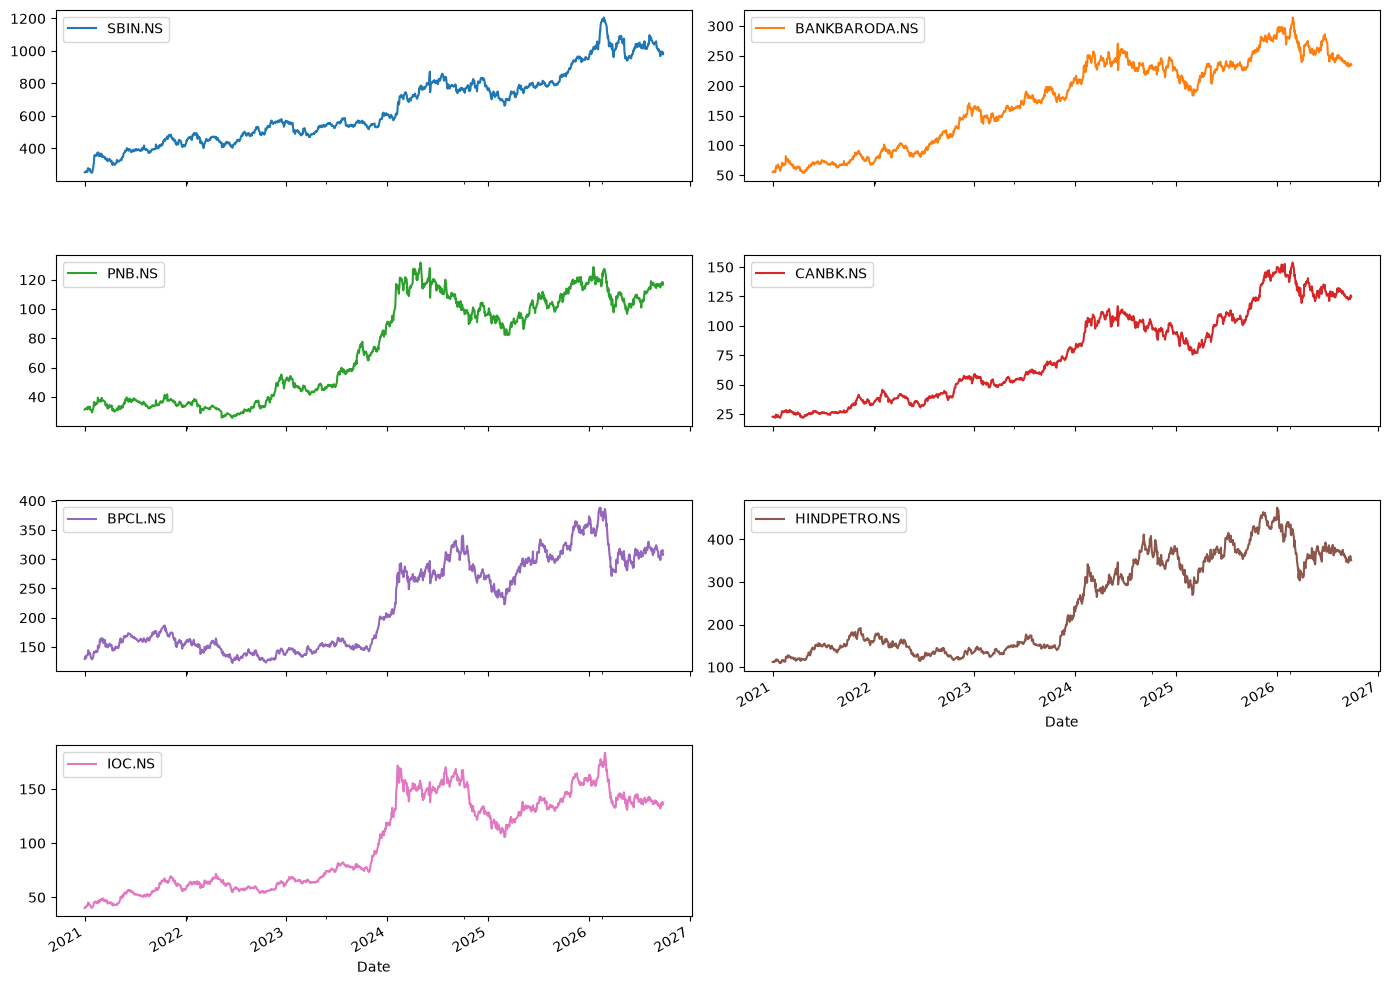

In [37]:
extra = ["SBIN.NS", "BANKBARODA.NS", "PNB.NS", "CANBK.NS",
         "BPCL.NS", "HINDPETRO.NS", "IOC.NS"]
px2 = yf.download(extra, start="2021-01-01", auto_adjust=True)["Close"]
px = px.join(px2, how="inner").dropna()
px.to_csv("../data/prices.csv")

train = px[px.index < split]
test = px[px.index >= split]
logp = np.log(px)

px[extra].plot(subplots=True, layout=(4, 2), figsize=(14, 10))
plt.tight_layout()
plt.show()

In [38]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from statsmodels.tsa.stattools import coint, adfuller

pairs = [("HDFCBANK.NS", "ICICIBANK.NS"), ("KOTAKBANK.NS", "AXISBANK.NS"),
         ("SBIN.NS", "BANKBARODA.NS"), ("BANKBARODA.NS", "PNB.NS"),
         ("PNB.NS", "CANBK.NS"), ("SBIN.NS", "CANBK.NS"),
         ("BPCL.NS", "HINDPETRO.NS"), ("BPCL.NS", "IOC.NS"), ("HINDPETRO.NS", "IOC.NS")]

rows = []
for a, b in pairs:
    ya, yb = np.log(train[a]), np.log(train[b])
    p = coint(ya, yb)[1]
    b_ab = sm.OLS(ya, sm.add_constant(yb)).fit().params[b]
    rows.append((a, b, round(p, 4), round(b_ab, 2),
                 round(adfuller(ya)[1], 3), round(adfuller(yb)[1], 3)))

pd.DataFrame(rows, columns=["A", "B", "coint p", "beta",
                            "A alone p", "B alone p"]).sort_values("coint p")

,A,B,coint p,beta,A alone p,B alone p
1,KOTAKBANK.NS,AXISBANK.NS,0.0003,-0.04,0.000,0.525
5,SBIN.NS,CANBK.NS,0.0106,0.53,0.236,0.699
2,SBIN.NS,BANKBARODA.NS,0.0417,0.53,0.236,0.687
0,HDFCBANK.NS,ICICIBANK.NS,0.0473,0.23,0.101,0.639
6,BPCL.NS,HINDPETRO.NS,0.3552,0.73,0.843,0.934
3,BANKBARODA.NS,PNB.NS,0.5473,0.88,0.687,0.894
4,PNB.NS,CANBK.NS,0.6542,0.92,0.894,0.699
7,BPCL.NS,IOC.NS,0.8125,0.62,0.843,0.733
8,HINDPETRO.NS,IOC.NS,0.8807,0.86,0.934,0.733


Intercept c: 4.1737
Hedge ratio beta: 0.5289


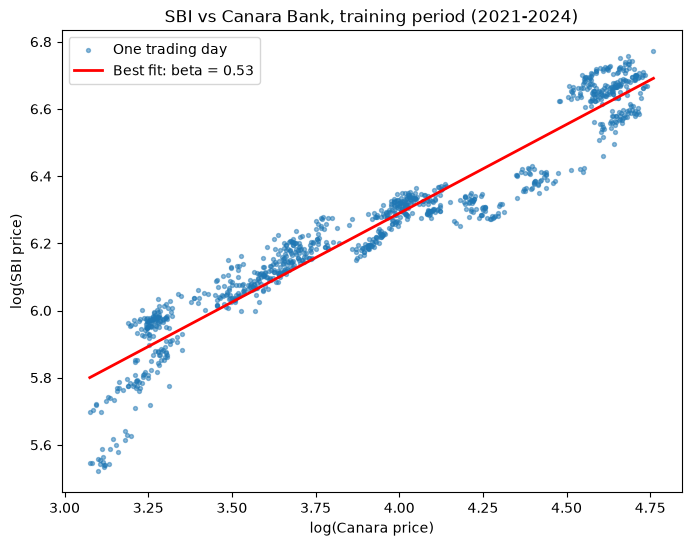

In [39]:
A, B = "SBIN.NS", "CANBK.NS"
x = np.log(train[B])
y = np.log(train[A])
model = sm.OLS(y, sm.add_constant(x)).fit()
c, beta = model.params["const"], model.params[B]
print("Intercept c:", round(c, 4))
print("Hedge ratio beta:", round(beta, 4))

plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=8, alpha=0.5, label="One trading day")
xs = np.linspace(x.min(), x.max(), 100)
plt.plot(xs, c + beta * xs, color="red", linewidth=2, label=f"Best fit: beta = {beta:.2f}")
plt.xlabel("log(Canara price)")
plt.ylabel("log(SBI price)")
plt.title("SBI vs Canara Bank, training period (2021-2024)")
plt.legend()
plt.savefig("../charts/regression_sbi_canara.png", dpi=150, bbox_inches="tight")
plt.show()

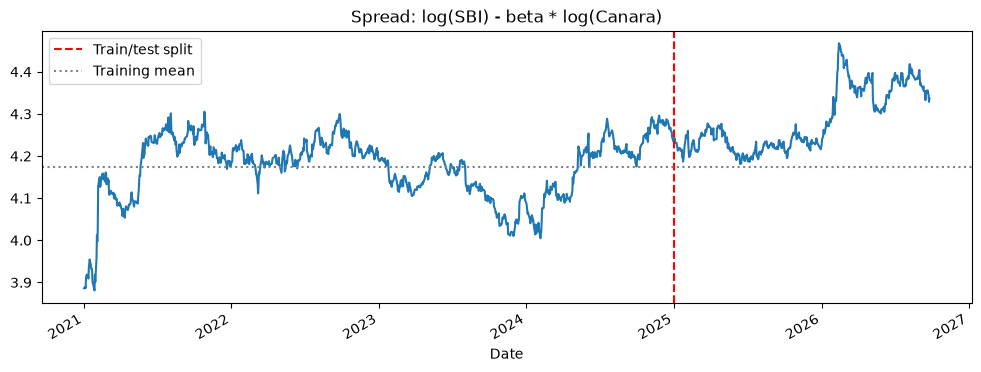

In [40]:
spread = logp[A] - beta * logp[B]

spread.plot(figsize=(12, 4), title="Spread: log(SBI) - beta * log(Canara)")
plt.axvline(pd.Timestamp(split), color="red", linestyle="--", label="Train/test split")
plt.axhline(spread[spread.index < split].mean(), color="grey", linestyle=":", label="Training mean")
plt.legend()
plt.savefig("../charts/spread_sbi_canara.png", dpi=150, bbox_inches="tight")
plt.show()

In [41]:
s = spread[spread.index < split]
lagged = sm.add_constant(s.shift(1).dropna())
lam = sm.OLS(s.diff().dropna(), lagged).fit().params.iloc[1]
half_life = -np.log(2) / lam
window = int(np.clip(round(2 * half_life), 20, 60))
print("Lambda:", round(lam, 4))
print("Half-life (days):", round(half_life, 1))
print("Z-score window:", window)

Lambda: -0.0195
Half-life (days): 35.6
Z-score window: 60


In [42]:
z = (spread - spread.rolling(window).mean()) / spread.rolling(window).std()
z.describe()

count    1363.000000
mean        0.098399
std         1.325450
min        -3.799752
25%        -0.980633
50%         0.098996
75%         1.088968
max         3.714191
dtype: float64

In [43]:
def make_positions(z, entry=2.0, exit=0.0, stop=3.5):
    pos, cur, locked = [], 0, False
    for zi in z:
        if np.isnan(zi):
            cur = 0
        elif cur == 0:
            if locked and abs(zi) < entry:
                locked = False
            if not locked:
                if entry < zi < stop:
                    cur = -1
                elif -stop < zi < -entry:
                    cur = 1
        elif cur == 1:
            if zi <= -stop:
                cur, locked = 0, True
            elif zi >= exit:
                cur = 0
        elif cur == -1:
            if zi >= stop:
                cur, locked = 0, True
            elif zi <= exit:
                cur = 0
        pos.append(cur)
    return pd.Series(pos, index=z.index)

pos = make_positions(z)
changes = pos.diff().fillna(0)
trade_log = pd.DataFrame({"z": z.round(2), "position": pos})[changes != 0]
trade_log

,z,position
Date,,
2021-05-21,2.52,-1
2021-08-12,-0.19,0
2021-08-20,-2.34,1
2021-09-13,0.15,0
2021-10-26,2.52,-1
2021-10-29,-0.85,0
2021-11-30,-2.17,1
2022-01-05,0.05,0
2022-03-03,-2.28,1


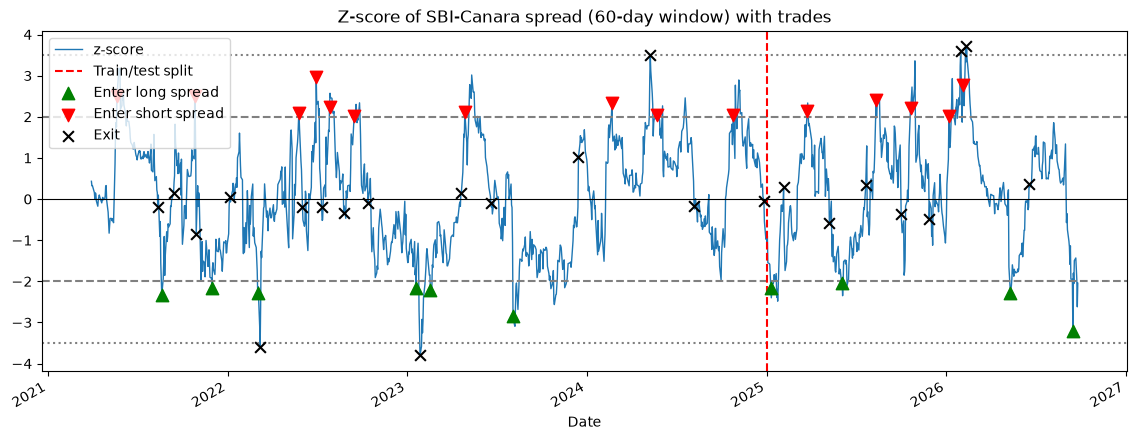

In [44]:
fig, ax = plt.subplots(figsize=(14, 5))
z.plot(ax=ax, lw=1, label="z-score")
for level, style in [(2, "--"), (-2, "--"), (3.5, ":"), (-3.5, ":")]:
    ax.axhline(level, color="grey", linestyle=style)
ax.axhline(0, color="black", lw=0.8)
ax.axvline(pd.Timestamp(split), color="red", linestyle="--", label="Train/test split")

prev = pos.shift(1).fillna(0)
long_in = z[(pos == 1) & (prev != 1)]
short_in = z[(pos == -1) & (prev != -1)]
exits = z[(pos == 0) & (prev != 0)]
ax.scatter(long_in.index, long_in, color="green", marker="^", s=80, zorder=3, label="Enter long spread")
ax.scatter(short_in.index, short_in, color="red", marker="v", s=80, zorder=3, label="Enter short spread")
ax.scatter(exits.index, exits, color="black", marker="x", s=60, zorder=3, label="Exit")

ax.set_title(f"Z-score of SBI-Canara spread ({window}-day window) with trades")
ax.legend(loc="upper left")
plt.savefig("../charts/zscore_trades.png", dpi=150, bbox_inches="tight")
plt.show()